In [3]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt



output_dir = Path("/home/a/arfaoui/rag_project/Output_1B")
output_summary = output_dir / "all_experiment_summaries.csv"



def classify_study(chunk_size, top_k):
    """
    Classify experiment into study types.
    """
    if top_k == 5 and chunk_size in [32, 128, 256]:
        return "chunk_size_study"
    elif chunk_size == 128 and top_k in [1, 5, 10]:
        return "topk_study"
    else:
        return "corner_configs"


# 4. Collect all summaries


records = []

for folder in output_dir.glob("*/summary.json"):
    with open(folder, "r") as f:
        summary = json.load(f)

    # Extract fields 
    chunk_size = summary.get("chunk_size")
    top_k = summary.get("top_k")

    record = {
        "model_name": "llama_3.2_1b",  
        "study_type": classify_study(chunk_size, top_k),
        "chunk_size": chunk_size,
        "top_k": top_k,
        "num_examples": summary.get("num_examples"),
        "avg_EM": summary.get("avg_EM"),
        "avg_F1": summary.get("avg_F1"),
        "avg_Recall_at_k_answer": summary.get("avg_Recall@k_answer"),
        "avg_Recall_at_k_support_titles": summary.get("avg_Recall@k_support_titles"),
        "latency_p50": summary.get("latency_p50"),
        "latency_p95": summary.get("latency_p95"),
        
    }

    records.append(record)


# 5. Create DataFrame and save CSV


df = pd.DataFrame(records)

# Sort for readability
df = df.sort_values(by=["chunk_size", "top_k"])

# Save to CSV
df.to_csv(output_summary, index=False)

print("Saved combined CSV to:", output_summary)
display(df)

Saved combined CSV to: /home/a/arfaoui/rag_project/Output_1B/all_experiment_summaries.csv


,model_name,study_type,chunk_size,top_k,num_examples,avg_EM,avg_F1,avg_Recall_at_k_answer,avg_Recall_at_k_support_titles,latency_p50,latency_p95
6,llama_3.2_1b,corner_configs,32,1,500,0.124,0.237417,0.246,0.736,0.566798,0.576203
7,llama_3.2_1b,chunk_size_study,32,5,500,0.176,0.290624,0.520,0.948,0.497197,0.739293
4,llama_3.2_1b,corner_configs,32,10,500,0.168,0.292134,0.594,0.978,0.735315,1.306900
3,llama_3.2_1b,topk_study,128,1,500,0.138,0.270920,0.410,0.850,0.570233,0.626501
2,llama_3.2_1b,chunk_size_study,128,5,500,0.198,0.359641,0.786,0.982,0.693115,1.007137
1,llama_3.2_1b,topk_study,128,10,500,0.206,0.368017,0.846,0.998,1.172601,1.477842
0,llama_3.2_1b,corner_configs,256,1,500,0.120,0.256585,0.428,0.842,0.575778,0.682024
8,llama_3.2_1b,chunk_size_study,256,5,500,0.204,0.360339,0.794,0.980,0.779264,1.138187
5,llama_3.2_1b,corner_configs,256,10,500,0.222,0.378884,0.864,0.996,1.384547,1.895536


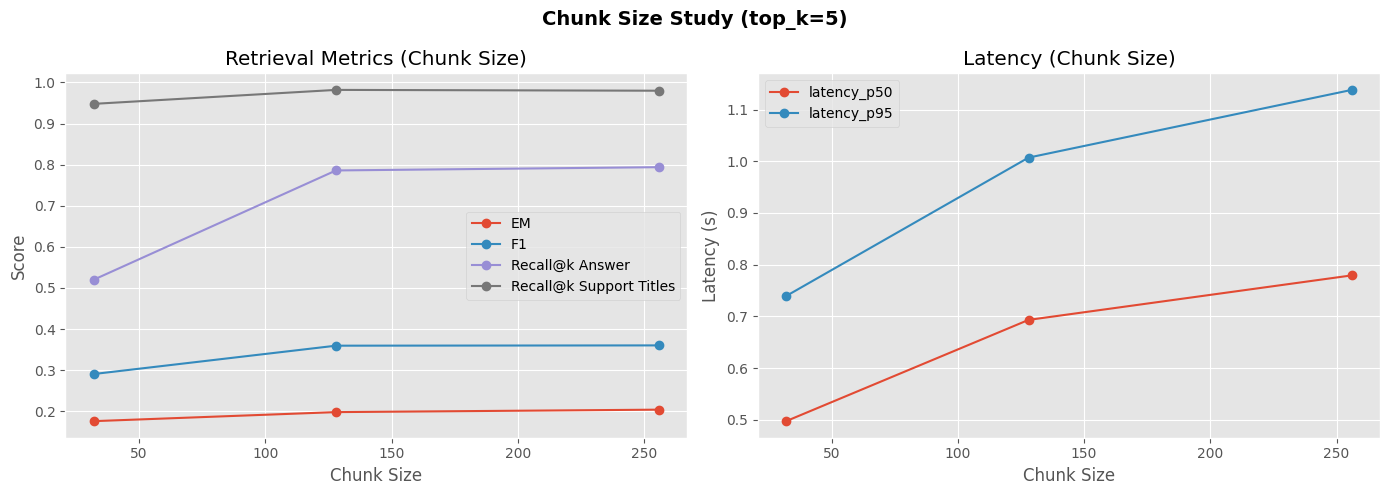

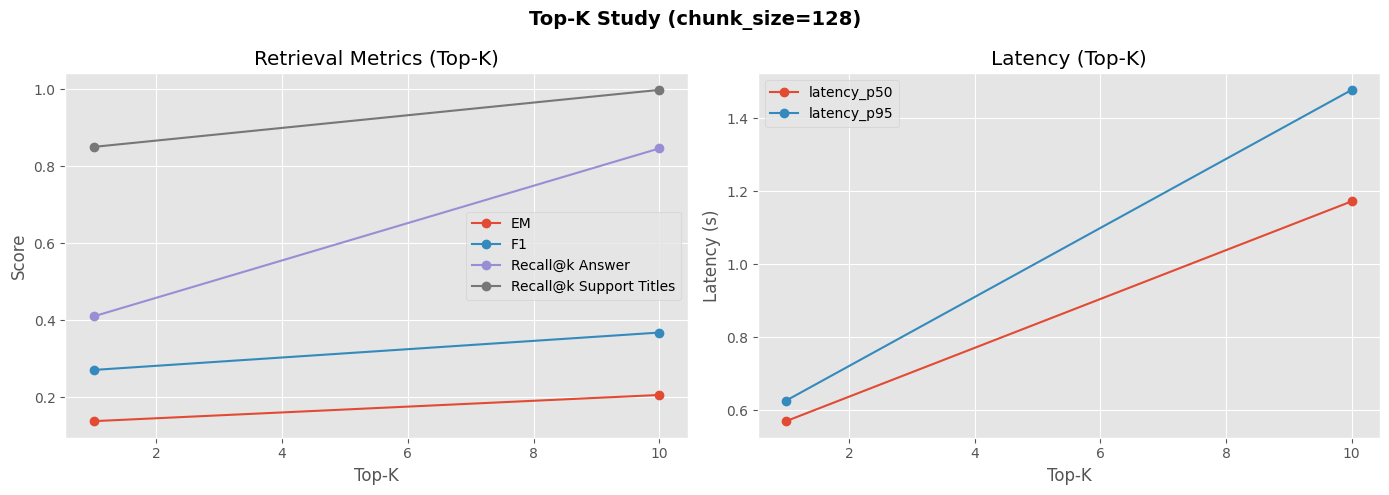

In [6]:
import matplotlib.pyplot as plt

metrics = ["avg_EM", "avg_F1", "avg_Recall_at_k_answer", "avg_Recall_at_k_support_titles"]
latency = ["latency_p50", "latency_p95"]
metric_labels = ["EM", "F1", "Recall@k Answer", "Recall@k Support Titles"]

# Study 1: Chunk Size (top_k=5) 
chunk_study = df[df["study_type"] == "chunk_size_study"].sort_values("chunk_size")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Chunk Size Study (top_k=5)", fontsize=14, fontweight="bold")

# Metrics
ax = axes[0]
for metric, label in zip(metrics, metric_labels):
    ax.plot(chunk_study["chunk_size"], chunk_study[metric], marker="o", label=label)
ax.set_xlabel("Chunk Size")
ax.set_ylabel("Score")
ax.set_title("Retrieval Metrics (Chunk Size)")
ax.legend()
ax.grid(True)

# Latency
ax = axes[1]
for col in latency:
    ax.plot(chunk_study["chunk_size"], chunk_study[col], marker="o", label=col)
ax.set_xlabel("Chunk Size")
ax.set_ylabel("Latency (s)")
ax.set_title("Latency (Chunk Size)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig(output_dir / "chunk_size_study.png", dpi=150)
plt.show()

# Study 2: Top-K (chunk_size=128)
topk_study = df[df["study_type"] == "topk_study"].sort_values("top_k")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Top-K Study (chunk_size=128)", fontsize=14, fontweight="bold")

# Metrics
ax = axes[0]
for metric, label in zip(metrics, metric_labels):
    ax.plot(topk_study["top_k"], topk_study[metric], marker="o", label=label)
ax.set_xlabel("Top-K")
ax.set_ylabel("Score")
ax.set_title("Retrieval Metrics (Top-K)")
ax.legend()
ax.grid(True)

# Latency
ax = axes[1]
for col in latency:
    ax.plot(topk_study["top_k"], topk_study[col], marker="o", label=col)
ax.set_xlabel("Top-K")
ax.set_ylabel("Latency (s)")
ax.set_title("Latency (Top-K)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig(output_dir / "topk_study.png", dpi=150)
plt.show()